In [25]:
import pandas as pd
import numpy as np
import keras
from sklearn.preprocessing import StandardScaler
import warnings
warnings.simplefilter('ignore', FutureWarning)
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from sklearn.metrics import mean_squared_error, r2_score

# Download and Clean the Data Set

In [2]:
filepath='https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0101EN/labs/data/concrete_data.csv'
concrete_data = pd.read_csv(filepath)

concrete_data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [3]:
concrete_data.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [4]:
concrete_data.value_counts()

Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  Coarse Aggregate  Fine Aggregate  Age  Strength
362.6   189.0               0.0      164.9  11.6              944.7             755.8           3    35.30       4
                                                                                                28   71.30       4
                                                                                                56   77.30       4
                                                                                                91   79.30       4
                                                                                                7    55.90       3
                                                                                                                ..
213.8   98.1                24.5     181.7  6.7               1066.0            785.5           28   40.23       1
                                                                                                56   47.13       1
                                                                                                100  49.97       1
214.9   53.8                121.9    155.6  9.6               1014.3            780.6           3    18.02       1
213.7   0.0                 174.7    154.8  10.2              1053.5            776.4           3    17.57       1
Name: count, Length: 1005, dtype: int64

In [5]:
concrete_data.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


# Split data into predictors and target

In [10]:
concrete_data_columns = concrete_data.columns
X = concrete_data.drop (columns ='Strength')
y = concrete_data['Strength']


In [22]:
#predictors_norm = (X - X.mean()) / X.std()


scaler = StandardScaler()
predictors_norm = scaler.fit_transform(X)
pd.DataFrame(predictors_norm, columns=predictors.columns).head()
n_cols = predictors_norm.shape[1]

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(predictors_norm, y, test_size=0.2, random_state=42)


# Build a Neural Network

In [24]:
class RegressionModel:
    def __init__(self, n_cols):
        self.n_cols = n_cols
        self.model = self.build_model()

    def build_model(self):
        model = Sequential()
        model.add(Input(shape=(self.n_cols,)))
        model.add(Dense(50, activation='relu'))
        model.add(Dense(50, activation='relu'))
        model.add(Dense(1))
        model.compile(optimizer='adam', loss='mean_squared_error')
        return model

    def train(self, X_train, y_train, epochs=100):
        return self.model.fit(X_train, y_train, epochs=epochs, verbose=0)

    def predict(self, X_test):
        return self.model.predict(X_test)

    def evaluate(self, X_test, y_test):
        return self.model.evaluate(X_test, y_test)

model = RegressionModel(n_cols)
model.train(predictors_norm, y)
predictions = model.predict(predictors_norm)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [26]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
MSE:  24.99
RMSE: 5.00
R²:   0.90


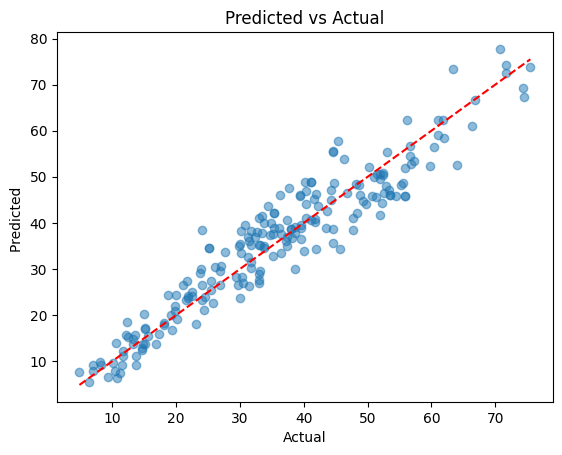

In [28]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted ')
plt.title('Predicted vs Actual')
plt.show()